In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
trader = pd.read_csv(r"D:\Data Science\Primetrade_DS Assignment\trader_historical_data.csv")

sentiment = pd.read_csv(r"D:\Data Science\Primetrade_DS Assignment\sentiment_fear_greed_index.csv")

# Data Preparation

In [4]:
trader.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [6]:
trader.shape

(211224, 16)

In [8]:
trader.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [10]:
trader.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [14]:
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [12]:
trader.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [19]:
trader.duplicated().sum()

0

In [20]:
trader["Coin"].nunique()

246

In [21]:
trader["Coin"].unique()[:20]

array(['@107', 'AAVE', 'DYDX', 'AIXBT', 'GMX', 'EIGEN', 'HYPE', 'SOL',
       'SUI', 'DOGE', 'ETH', 'kPEPE', 'TRUMP', 'ONDO', 'ENA', 'LINK',
       'XRP', 'S', 'BNB', 'BERA'], dtype=object)

In [22]:
trader["Side"].value_counts()

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

In [23]:
trader["Direction"].value_counts()

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

In [24]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [25]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [26]:
sentiment.shape

(2644, 4)

In [27]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [28]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [29]:
sentiment.duplicated().sum()

0

In [30]:
trader["Timestamp IST"] = pd.to_datetime(trader["Timestamp IST"], dayfirst=True)

In [31]:
trader["Timestamp IST"].dtype

dtype('<M8[ns]')

In [32]:
trader["date"] = trader["Timestamp IST"].dt.date

In [33]:
trader[["Timestamp IST", "date"]].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [36]:
trader["date"].dtype

dtype('O')

In [37]:
trader["date"] = pd.to_datetime(trader["date"])

In [38]:
trader["date"].dtype

dtype('<M8[ns]')

In [34]:
sentiment["date"] = pd.to_datetime(sentiment["date"])

In [35]:
sentiment["date"].dtype

dtype('<M8[ns]')

In [39]:
merged = pd.merge(trader, sentiment, on="date", how="left")

In [40]:
merged.shape

(211224, 20)

In [41]:
merged[["classification", "value"]].isnull().sum()

classification    6
value             6
dtype: int64

In [42]:
merged[merged["classification"].isnull()][["Timestamp IST", "date"]]

,Timestamp IST,date
727,2024-10-26 04:44:00,2024-10-26
728,2024-10-26 04:52:00,2024-10-26
729,2024-10-26 04:52:00,2024-10-26
730,2024-10-26 04:52:00,2024-10-26
731,2024-10-26 04:52:00,2024-10-26
732,2024-10-26 04:53:00,2024-10-26


In [43]:
sentiment[sentiment["date"] == "2024-10-26"]

,timestamp,value,classification,date


In [44]:
merged = merged.dropna(subset=["classification"])

In [45]:
merged.shape

(211218, 20)

# EDA (Exploratory Data Analysis)

In [46]:
merged["Closed PnL"].describe()

count    211218.000000
mean         48.549304
std         917.989791
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.790132
max      135329.090100
Name: Closed PnL, dtype: float64

In [47]:
(merged["Closed PnL"] == 0).sum()

106816

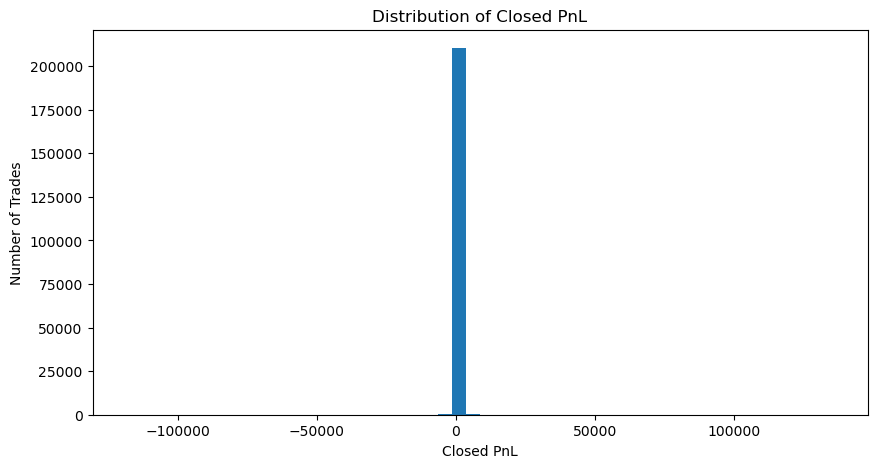

In [48]:
plt.figure(figsize=(10,5))
plt.hist(merged["Closed PnL"], bins=50)
plt.title("Distribution of Closed PnL")
plt.xlabel("Closed PnL")
plt.ylabel("Number of Trades")
plt.show()

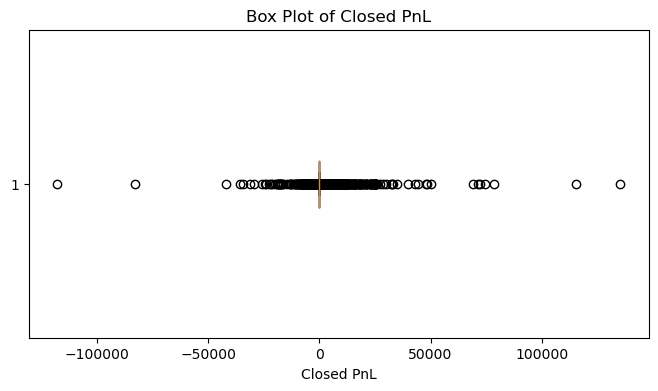

In [49]:
plt.figure(figsize=(8,4))
plt.boxplot(merged["Closed PnL"], vert=False)
plt.title("Box Plot of Closed PnL")
plt.xlabel("Closed PnL")
plt.show()

In [50]:
merged.groupby("classification")["Closed PnL"].describe()

,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme Fear,21400.0,34.537862,1136.056091,-31036.69194,0.0,0.0,5.635032,115287.00000
Extreme Greed,39992.0,67.892861,766.828294,-10259.46800,0.0,0.0,10.028709,44223.45187
Fear,61837.0,54.290400,935.355438,-35681.74723,0.0,0.0,5.590856,135329.09010
Greed,50303.0,42.743559,1116.028390,-117990.10410,0.0,0.0,4.944105,74530.52371
Neutral,37686.0,34.307718,517.122220,-24500.00000,0.0,0.0,3.995795,48504.09555


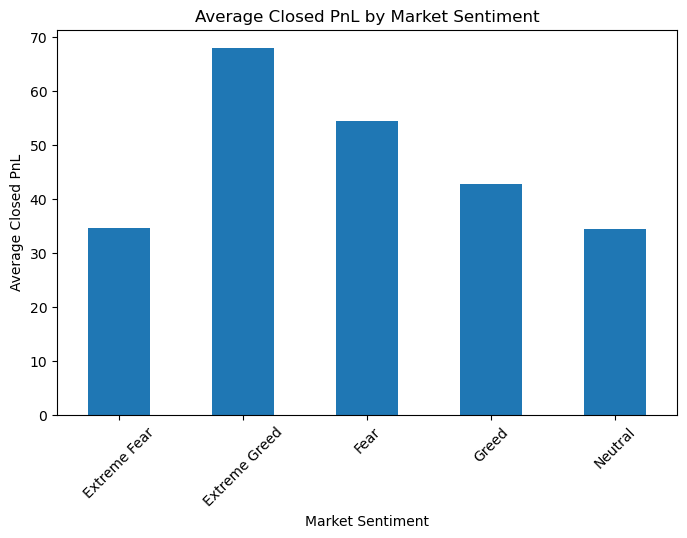

In [51]:
mean_pnl = merged.groupby("classification")["Closed PnL"].mean()
plt.figure(figsize=(8,5))
mean_pnl.plot(kind="bar")
plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)
plt.show()

In [52]:
merged["classification"].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

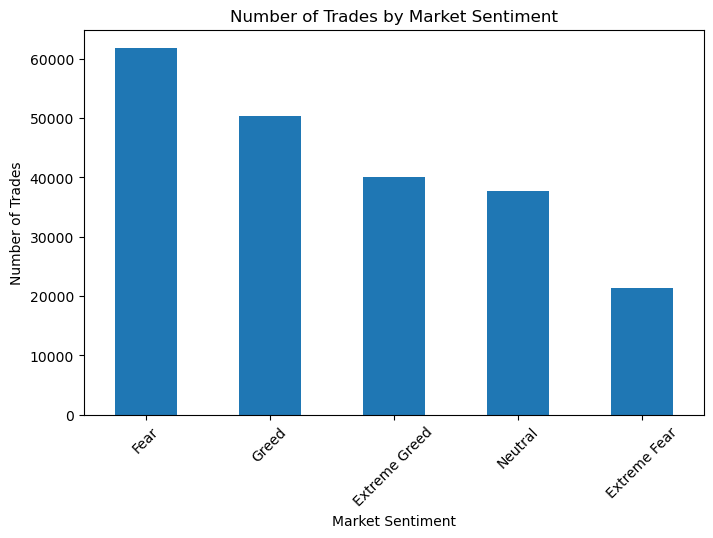

In [53]:
trade_count = merged["classification"].value_counts()
plt.figure(figsize=(8,5))
trade_count.plot(kind="bar")
plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.show()

In [54]:
pd.crosstab(merged["classification"], merged["Side"])

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


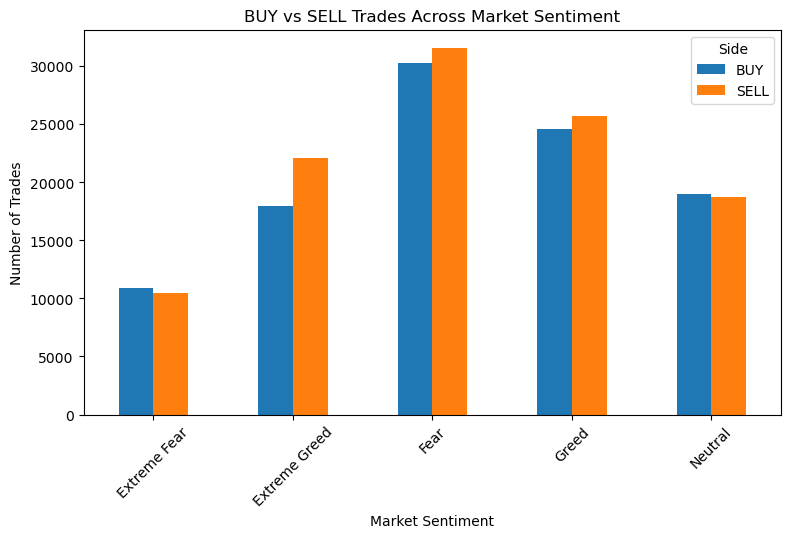

In [55]:
buy_sell = pd.crosstab(merged["classification"], merged["Side"])
buy_sell.plot(kind="bar", figsize=(9,5))
plt.title("BUY vs SELL Trades Across Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.show()

In [56]:
merged.groupby("Coin")["Closed PnL"].sum().sort_values(ascending=False).head(10)

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64

In [57]:
merged[merged["Coin"] == "@107"].head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [59]:
merged[merged["Coin"] != "@107"] \
    .groupby("Coin")["Closed PnL"] \
    .sum() \
    .sort_values(ascending=False) \
    .head(10)

Coin
HYPE         1.948485e+06
SOL          1.639556e+06
ETH          1.319979e+06
BTC          8.680447e+05
MELANIA      3.903511e+05
ENA          2.173295e+05
SUI          1.992688e+05
ZRO          1.837778e+05
DOGE         1.475432e+05
PURR/USDC    7.526106e+04
Name: Closed PnL, dtype: float64

In [60]:
pd.pivot_table(merged, values="Closed PnL", index="classification", columns="Side", aggfunc="mean")

Side,BUY,SELL
classification,,
Extreme Fear,34.114627,34.980106
Extreme Greed,10.498927,114.584643
Fear,63.927104,45.049641
Greed,25.002302,59.691091
Neutral,29.227429,39.456408


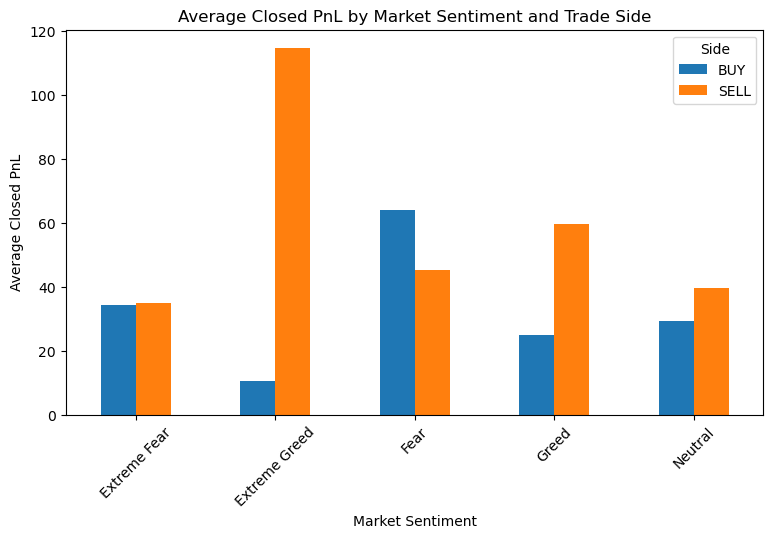

In [61]:
pivot = pd.pivot_table(merged, values="Closed PnL", index="classification", columns="Side", aggfunc="mean")
pivot.plot(kind="bar", figsize=(9,5))
plt.title("Average Closed PnL by Market Sentiment and Trade Side")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)
plt.show()

# Exploratory Data Analysis (EDA) Summary

The trader dataset was merged with the Bitcoin Fear & Greed Index using the trade date to analyze the relationship between market sentiment and trader performance. After preprocessing, the final dataset contained 211,218 trading records.

The EDA focused on understanding the distribution of trader profits, trading activity across different market sentiments, BUY and SELL behavior, and profitability under different market conditions. Multiple statistical summaries and visualizations were used to identify trends and compare trader performance across the Fear & Greed categories.

# Key Findings

1. More than 50% of the trades had a Closed PnL of zero, indicating that a large proportion of trades resulted in no realized profit or loss.

2. Trader performance varied across different market sentiment categories. The highest average Closed PnL was observed during **Extreme Greed**, while **Neutral** and **Extreme Fear** showed the lowest average profits.

3. Trading activity was highest during **Fear**, suggesting that traders were more active during bearish market conditions.

4. BUY and SELL trades were generally balanced across all market sentiment categories. However, **Extreme Greed** showed noticeably higher SELL activity compared to BUY activity.

5. During **Fear**, BUY trades generated a higher average Closed PnL than SELL trades. In contrast, SELL trades outperformed BUY trades during **Greed** and especially **Extreme Greed**.

6. The distribution of Closed PnL was highly skewed, with several extreme profit and loss outliers, indicating high variability in trader performance.

7. Among the identifiable trading assets, HYPE, SOL, ETH, and BTC contributed the highest total realized profits.

# Conclusion

The analysis indicates that trader performance varies across different Bitcoin market sentiment conditions. While the highest trading activity occurred during **Fear**, the highest average realized profit (Closed PnL) was observed during **Extreme Greed**.

Trading behavior also differed across market conditions. During **Fear**, BUY trades achieved higher average realized profits than SELL trades. In contrast, SELL trades generated significantly higher average profits during **Greed** and especially **Extreme Greed**.

Overall, the analysis suggests that market sentiment is associated with differences in trader activity and realized profitability. However, the results demonstrate an association rather than a causal relationship, as other market factors may also influence trading outcomes.

# Business Recommendations

Based on the analysis, the following recommendations are suggested:

1. **Incorporate Market Sentiment into Trading Decisions**
   - Bitcoin Fear & Greed Index can be used as an additional market indicator when evaluating trading opportunities.

2. **Monitor Trading Strategies Across Different Sentiment Phases**
   - Since BUY trades performed better during Fear while SELL trades performed better during Greed and Extreme Greed, trading strategies could be evaluated separately for different market sentiment conditions.

3. **Implement Risk Management for Extreme Market Conditions**
   - The presence of large profit and loss outliers highlights the importance of position sizing, stop-loss mechanisms, and portfolio risk management.

4. **Further Investigate High-Performing Assets**
   - Assets such as HYPE, SOL, ETH, and BTC generated the highest total realized profits in this dataset. Additional analysis could determine whether this is due to higher trading frequency, larger trade sizes, or better risk-adjusted performance.

5. **Expand Future Analysis**
   - Future studies could include holding period, leverage, market volatility, and trader-level performance metrics to better understand the drivers of profitability.